# Лабораторная работа 1
Выполнила студентка группы 6401 Иванова Дарья

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 2: задания 1 и 2 на наборе данных MNIST



Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [2]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [3]:
digits = load_digits()

In [4]:
X = digits.data
y = digits.target

print('data shape: ', X.shape)
print('labels shape: ', y.shape)

data shape:  (1797, 64)
labels shape:  (1797,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.

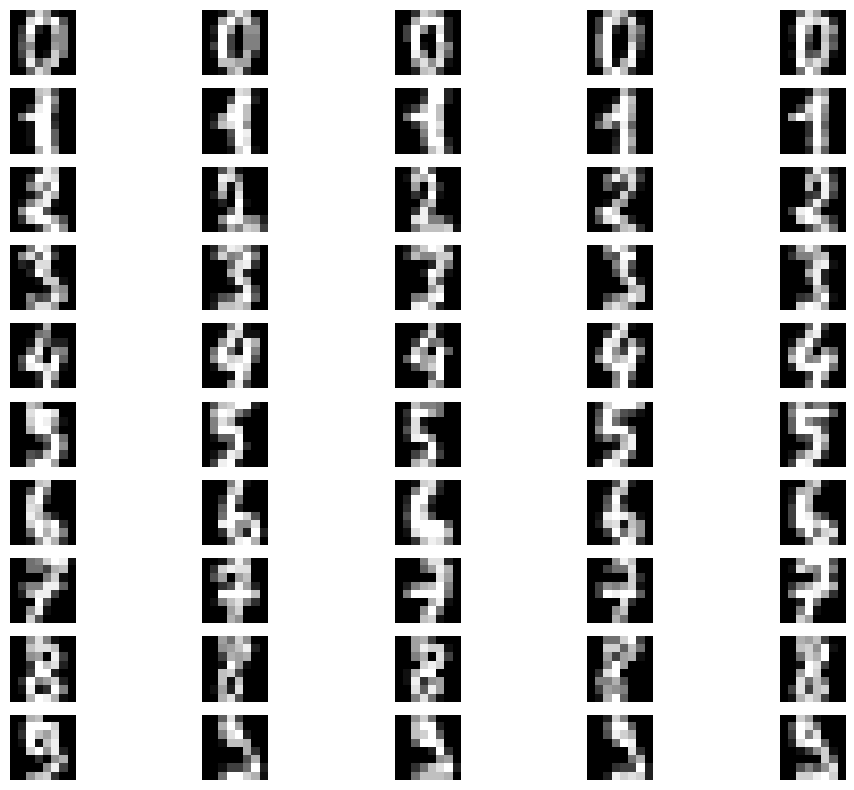

In [5]:
classes = np.unique(y)
examples_per_class = 5

plt.figure(figsize=(12, 10))

for row, cls in enumerate(classes):
    class_indices = np.where(y == cls)[0][:examples_per_class]

    for col, idx in enumerate(class_indices):
        image = X[idx].reshape(8, 8)

        plt.subplot(len(classes), examples_per_class, row * examples_per_class + col + 1)
        plt.imshow(image, cmap='gray')
        
        if col == 0:
            plt.ylabel(f'Class {cls}')
        
        plt.axis('off')


1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1437, 64)
y_train shape: (1437,)
X_test shape: (360, 64)
y_test shape: (360,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [7]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [8]:
y_test_pred = classifier.predict(X_test, k=1, num_loops=0)
print(y_test_pred)

[5. 2. 8. 1. 7. 2. 6. 2. 6. 5. 0. 5. 9. 3. 4. 4. 2. 4. 9. 9. 6. 3. 8. 1.
 2. 5. 6. 0. 3. 4. 6. 7. 2. 6. 6. 6. 6. 5. 0. 9. 1. 7. 9. 6. 5. 7. 5. 2.
 7. 5. 0. 1. 5. 5. 3. 2. 4. 0. 0. 2. 7. 5. 6. 1. 3. 7. 6. 5. 7. 0. 9. 0.
 3. 8. 2. 5. 8. 2. 3. 5. 9. 3. 2. 7. 9. 6. 8. 1. 0. 1. 2. 9. 4. 4. 1. 2.
 7. 8. 4. 2. 6. 8. 3. 7. 3. 9. 6. 1. 1. 0. 9. 2. 1. 6. 3. 4. 8. 7. 1. 0.
 0. 4. 6. 5. 8. 2. 8. 1. 3. 0. 0. 8. 6. 4. 3. 9. 3. 3. 3. 3. 0. 7. 0. 0.
 1. 9. 5. 8. 1. 5. 0. 6. 6. 6. 6. 1. 7. 7. 6. 7. 7. 8. 7. 3. 6. 5. 9. 0.
 3. 8. 0. 9. 8. 1. 9. 5. 9. 5. 8. 9. 9. 7. 9. 1. 9. 5. 4. 7. 3. 0. 4. 9.
 7. 7. 5. 6. 5. 8. 3. 4. 5. 4. 9. 2. 5. 5. 2. 1. 3. 8. 8. 9. 3. 6. 1. 0.
 1. 4. 0. 5. 5. 6. 6. 7. 4. 3. 8. 4. 1. 0. 7. 9. 2. 1. 4. 8. 4. 2. 4. 0.
 0. 0. 2. 6. 7. 0. 4. 5. 2. 2. 9. 0. 4. 6. 8. 2. 3. 9. 2. 3. 0. 6. 8. 7.
 1. 4. 4. 1. 1. 6. 3. 8. 1. 2. 5. 7. 8. 3. 2. 0. 3. 4. 1. 9. 9. 9. 6. 3.
 7. 1. 6. 9. 4. 7. 1. 8. 1. 3. 0. 5. 3. 4. 1. 9. 3. 5. 4. 7. 4. 1. 5. 1.
 5. 0. 9. 8. 4. 2. 3. 8. 4. 1. 2. 0. 1. 1. 4. 4. 5.

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


In [9]:
dists = classifier.compute_distances_no_loops(X_test)

print("Distance matrix shape:", dists.shape)

Distance matrix shape: (360, 1437)


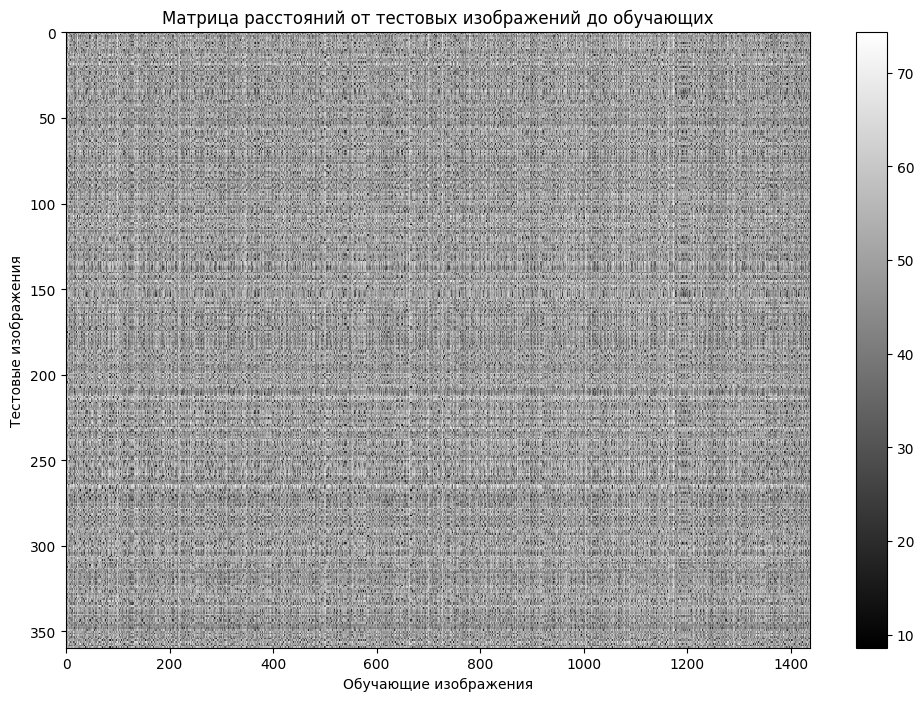

In [10]:
plt.figure(figsize=(12, 8))
plt.imshow(dists, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xlabel('Обучающие изображения')
plt.ylabel('Тестовые изображения')
plt.title('Матрица расстояний от тестовых изображений до обучающих')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [11]:
y_test_pred = classifier.predict(X_test, k=1, num_loops=0)

accuracy = np.mean(y_test_pred == y_test)

print("Доля правильно классифицированных изображений:", accuracy)

Доля правильно классифицированных изображений: 0.9861111111111112


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

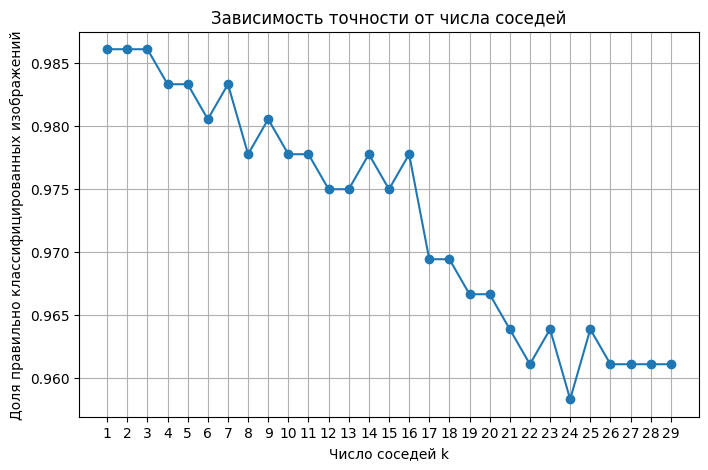

In [12]:
k_values = range(1, 30)
accuracies = []

for k in k_values:
    y_test_pred = classifier.predict(X_test, k=k, num_loops=0)
    accuracy = np.mean(y_test_pred == y_test)
    accuracies.append(accuracy)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Число соседей k')
plt.ylabel('Доля правильно классифицированных изображений')
plt.title('Зависимость точности от числа соседей')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


Средняя accuracy по кросс-валидации:
k = 1: 0.9861
k = 2: 0.9812
k = 3: 0.9840
k = 4: 0.9798
k = 5: 0.9826
k = 6: 0.9819
k = 7: 0.9819
k = 8: 0.9784
k = 9: 0.9770
k = 10: 0.9749

Лучшее значение k: 1
Лучшая средняя accuracy: 0.9861


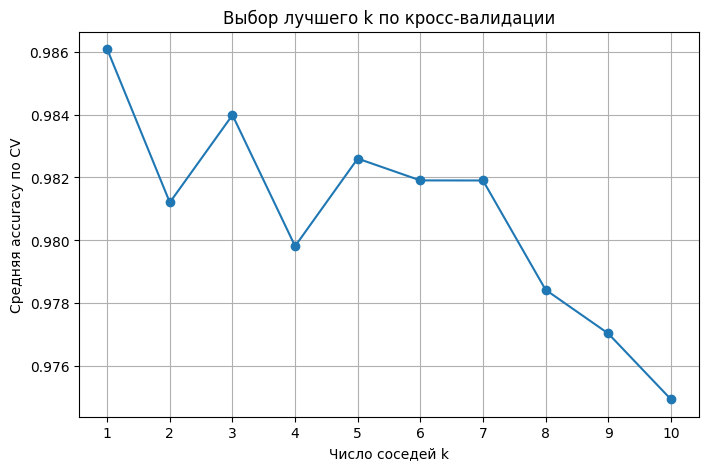

In [13]:
k_values = range(1, 11)
cv_scores = []

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    fold_scores = []
    
    for train_idx, val_idx in cv.split(X_train):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        classifier = KNearestNeighbor()
        classifier.train(X_train_fold, y_train_fold)
        
        y_val_pred = classifier.predict(X_val_fold, k=k, num_loops=0)
        accuracy = np.mean(y_val_pred == y_val_fold)
        fold_scores.append(accuracy)
    
    cv_scores.append(np.mean(fold_scores))

best_k = k_values[np.argmax(cv_scores)]
best_score = np.max(cv_scores)

print("Средняя accuracy по кросс-валидации:")
for k, score in zip(k_values, cv_scores):
    print(f"k = {k}: {score:.4f}")

print(f"\nЛучшее значение k: {best_k}")
print(f"Лучшая средняя accuracy: {best_score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Число соседей k')
plt.ylabel('Средняя accuracy по CV')
plt.title('Выбор лучшего k по кросс-валидации')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [14]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

y_test_pred = classifier.predict(X_test, k=best_k, num_loops=0)

accuracy = np.mean(y_test_pred == y_test)

print(f"Выбранное значение k: {best_k}")
print(f"Доля правильно классифицированных изображений на тестовой выборке: {accuracy:.4f}")

Выбранное значение k: 1
Доля правильно классифицированных изображений на тестовой выборке: 0.9861


1.11 Сделайте выводы по результатам 1 части задания.

 Классификатор показал высокое качество на тестовой выборке: доля правильно классифицированных изображений составила 0.9861. По графику зависимости точности от числа соседей видно, что наилучшие результаты достигаются при малых значениях k, а при увеличении числа соседей качество постепенно снижается.

С помощью кросс-валидации было установлено, что оптимальным является значение k = 1 => для данного датасета ближайший сосед чаще всего уже позволяет правильно определить класс изображения, а учет большего числа соседей может приводить к ухудшению результата из-за попадания в голосование похожих объектов других классов. В целом, метод k ближайших соседей хорошо справляется с задачей распознавания цифр на данном наборе данных.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [15]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42, 
    stratify=y_temp
)
num_dev = 500
mask = np.random.choice(X_train.shape[0], num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1077, 64)
y_train shape: (1077,)
X_val shape: (360, 64)
y_val shape: (360,)
X_test shape: (360, 64)
y_test shape: (360,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[0.00000000e+00 3.09192201e-01 5.15598886e+00 1.18142990e+01
 1.18876509e+01 5.86443825e+00 1.32869081e+00 1.34633240e-01
 4.64252553e-03 1.90250696e+00]


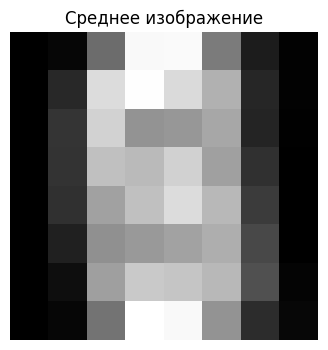

X_train shape: (1077, 65)
X_val shape: (360, 65)
X_test shape: (360, 65)


In [16]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])

plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((8, 8)), cmap='gray')
plt.title('Среднее изображение')
plt.axis('off')
plt.show()

X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [17]:

from scripts.classifiers.linear_svm import svm_loss_naive
import time


W = np.random.randn(64, 10) * 0.0001

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.990405



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [18]:
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -1.226000 analytic: -1.226000, relative error: 1.488543e-10
numerical: 0.002000 analytic: 0.002000, relative error: 1.916572e-08
numerical: 3.162000 analytic: 3.162000, relative error: 2.298007e-11
numerical: -3.316000 analytic: -3.316000, relative error: 1.084588e-10
numerical: -0.696000 analytic: -0.696000, relative error: 1.674691e-10
numerical: 5.440000 analytic: 5.440000, relative error: 2.254112e-11
numerical: 1.268000 analytic: 1.268000, relative error: 6.179678e-11
numerical: 0.322000 analytic: 0.322000, relative error: 5.470780e-10
numerical: 0.242000 analytic: 0.242000, relative error: 4.696244e-10
numerical: 5.806000 analytic: 5.806000, relative error: 1.313482e-11
numerical: 0.273069 analytic: 0.273069, relative error: 2.811366e-10
numerical: 0.011856 analytic: 0.011856, relative error: 6.938032e-09
numerical: 1.629034 analytic: 1.629034, relative error: 6.628233e-11
numerical: 7.965974 analytic: 7.965974, relative error: 5.497080e-11
numerical: -0.860891 analyti

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [19]:
from scripts.classifiers.linear_svm import svm_loss_vectorized
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.005349s
Vectorized loss and gradient: computed in 0.000361s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [20]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 23.902167
iteration 100 / 1500: loss 14.439094
iteration 200 / 1500: loss 10.954183
iteration 300 / 1500: loss 9.690383
iteration 400 / 1500: loss 9.215808
iteration 500 / 1500: loss 9.043484
iteration 600 / 1500: loss 8.985958
iteration 700 / 1500: loss 8.959488
iteration 800 / 1500: loss 8.950626
iteration 900 / 1500: loss 8.955756
iteration 1000 / 1500: loss 8.948854
iteration 1100 / 1500: loss 8.946067
iteration 1200 / 1500: loss 8.947805
iteration 1300 / 1500: loss 8.946144
iteration 1400 / 1500: loss 8.946478
That took 0.063073s


In [21]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.874652
validation accuracy: 0.847222


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [22]:
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]
regularization_strengths = [1e-4, 1e-3, 1e-2, 1e-1]

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.hstack([y_train, y_val])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
best_val = -1
best_lr = None
best_reg = None

for lr in learning_rates:
    for reg in regularization_strengths:
        fold_accuracies = []

        for train_idx, val_idx in kf.split(X_trainval):
            X_train_fold = X_trainval[train_idx]
            y_train_fold = y_trainval[train_idx]
            X_val_fold = X_trainval[val_idx]
            y_val_fold = y_trainval[val_idx]

            svm = LinearSVM()
            svm.train(
                X_train_fold, y_train_fold,
                learning_rate=lr,
                reg=reg,
                num_iters=1500,
                batch_size=200,
                verbose=False
            )

            y_train_pred = svm.predict(X_train_fold)
            train_accuracy = np.mean(y_train_fold == y_train_pred)

            y_val_pred = svm.predict(X_val_fold)
            val_accuracy = np.mean(y_val_fold == y_val_pred)

            fold_accuracies.append(val_accuracy)

        mean_val_accuracy = np.mean(fold_accuracies)
        results[(lr, reg)] = mean_val_accuracy

        if mean_val_accuracy > best_val:
            best_val = mean_val_accuracy
            best_lr = lr
            best_reg = reg

for (lr, reg), mean_val_acc in results.items():
    print('lr %e reg %e mean cv accuracy: %f' % (lr, reg, mean_val_acc))

print('\nЛучшие параметры:')
print('learning_rate =', best_lr)
print('reg =', best_reg)
print('best mean cv accuracy =', best_val)

best_svm = LinearSVM()
best_svm.train(
    X_trainval, y_trainval,
    learning_rate=best_lr,
    reg=best_reg,
    num_iters=1500,
    batch_size=200,
    verbose=False
)

y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)

print('test accuracy =', test_accuracy)

lr 1.000000e-04 reg 1.000000e-04 mean cv accuracy: 0.959647
lr 1.000000e-04 reg 1.000000e-03 mean cv accuracy: 0.958256
lr 1.000000e-04 reg 1.000000e-02 mean cv accuracy: 0.960342
lr 1.000000e-04 reg 1.000000e-01 mean cv accuracy: 0.958256
lr 5.000000e-04 reg 1.000000e-04 mean cv accuracy: 0.961034
lr 5.000000e-04 reg 1.000000e-03 mean cv accuracy: 0.958946
lr 5.000000e-04 reg 1.000000e-02 mean cv accuracy: 0.960339
lr 5.000000e-04 reg 1.000000e-01 mean cv accuracy: 0.961728
lr 1.000000e-03 reg 1.000000e-04 mean cv accuracy: 0.962430
lr 1.000000e-03 reg 1.000000e-03 mean cv accuracy: 0.961031
lr 1.000000e-03 reg 1.000000e-02 mean cv accuracy: 0.962427
lr 1.000000e-03 reg 1.000000e-01 mean cv accuracy: 0.961034
lr 5.000000e-03 reg 1.000000e-04 mean cv accuracy: 0.962425
lr 5.000000e-03 reg 1.000000e-03 mean cv accuracy: 0.958941
lr 5.000000e-03 reg 1.000000e-02 mean cv accuracy: 0.961029
lr 5.000000e-03 reg 1.000000e-01 mean cv accuracy: 0.961034

Лучшие параметры:
learning_rate = 0.001

2.9 Сделайте выводы по второй части задания

Был реализован линейный классификатор SVM и проведена предварительная обработка данных: из изображений было вычтено среднее изображение, после чего добавлен дополнительный признак для учета свободного члена. 

Была проверена корректность вычисления функции потерь и градиента: наивная и векторизованная реализации дали одинаковый результат, при этом векторизованная версия работала быстрее. После обучения линейного SVM удалось получить качество 0.8472 на валидационной выборке, а после подбора гиперпараметров с помощью кросс-валидации лучшее качество составило 0.9638 на валидации и 0.9583 на тестовой выборке.

Подбор коэффициента регуляризации заметно улучшил качество модели. В целом, линейный SVM хорошо решает задачу классификации  цифр, хотя по качеству он немного уступает методу k ближайших соседей. Но оба метода показывают высокое качество.